<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 5: Reusable Hydrology Skills for AI-Assisted Coding</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  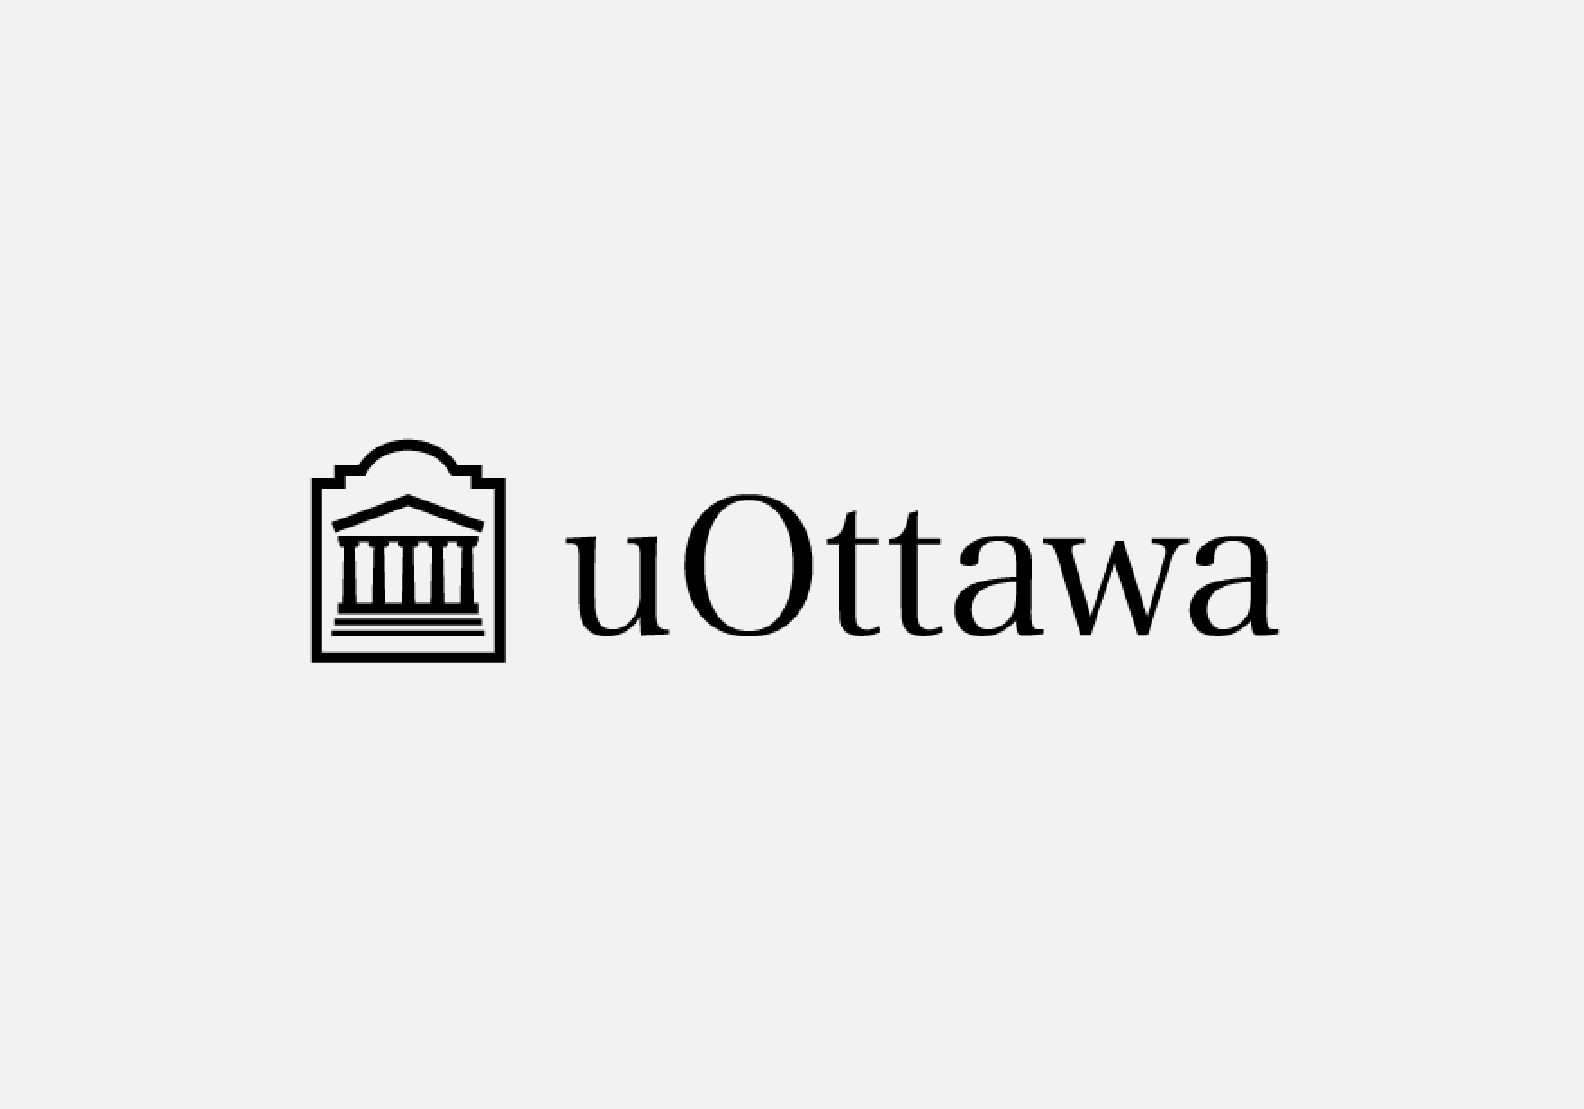
</div>

This notebook teaches how reusable instruction blocks can carry hydrology conventions into repeated coding tasks. The example uses flood-frequency analysis and a standardized streamflow quality report.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The hydrological example is based on flood-frequency and plotting-position references:

- England, J. F., Jr., Cohn, T. A., Faber, B. A., Stedinger, J. R., Thomas, W. O., Jr., Veilleux, A. G., Kiang, J. E., and Mason, R. R., Jr. (2018). *Guidelines for determining flood flow frequency: Bulletin 17C*. U.S. Geological Survey Techniques and Methods 4-B5. https://doi.org/10.3133/tm4B5
- Interagency Advisory Committee on Water Data. (1982). *Guidelines for determining flood flow frequency: Bulletin 17B*. https://doi.org/10.3133/70275162
- Weibull, W. (1939). *A statistical theory of the strength of materials*. Royal Swedish Institute for Engineering Research, Proceedings No. 151.

Scientific note: this notebook uses a simplified annual-maximum and Weibull plotting-position workflow for teaching. It does not implement full Bulletin 17C Expected Moments Algorithm or Log-Pearson Type III fitting.

## 2. Learning Goal

A reusable skill is a compact instruction block that the assistant can apply repeatedly. It is useful when a task depends on rules that should not be retyped every session.

Two useful skill types are:

1. **Domain skill:** hydrology conventions, units, formulas, and edge cases.
2. **Workflow skill:** fixed steps for a repeated report or analysis.

Hydrology target: encode flood-frequency conventions and apply them to a small streamflow example.

## 3. Libraries

The notebook uses standard Python tools for dates, arrays, tables, and plots.

In [ ]:
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

USGS_MISSING = -999999.0

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Two Reusable Skill Cards

A skill card should be short enough to inspect but specific enough to prevent repeated mistakes.

In [ ]:
hydrology_domain_skill = """Hydrology domain skill
- Treat discharge as cfs unless another unit is stated.
- Remove USGS missing-data sentinel values equal to -999999 before calculations.
- Flag negative discharge values as physically invalid.
- Use water year N = Oct 1 of year N-1 through Sep 30 of year N.
- For flood annual maxima, use one peak per water year.
- For simplified Weibull flood plotting positions, rank 1 is the largest annual maximum and T = (n + 1) / rank.
- Warn that short records are not reliable for large return periods.
"""

flow_report_skill = """Streamflow report skill
1. Check data quality: total records, missing sentinels, negative values, date range.
2. Compute clean-data statistics: mean, median, standard deviation, minimum, maximum.
3. Extract annual maxima by water year.
4. Flag potential outliers for review; do not remove them automatically.
5. Assign a quality grade: GOOD, FAIR, or POOR.
"""

print(hydrology_domain_skill)
print(flow_report_skill)

## 5. Concept Graph

A skill replaces repeated prompting with a reusable instruction layer.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Repeated Rule', 'Water year, units, sentinel'),
    ('Skill Card', 'Stored instruction'),
    ('Assistant Task', 'Implementation or report'),
    ('Verification', 'Tests and checks'),
    ('Reusable Output', 'Same structure next time'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('Reusable Skill Pattern', pad=12)
plt.show()

## 6. Sample Streamflow Record

The sample record is intentionally small and contains missing-data sentinels. It is suitable for teaching the workflow, not for real flood-frequency estimation.

In [ ]:
sample_dates = [
    date(2018, 9, 30), date(2018, 10, 1), date(2019, 2, 15), date(2019, 9, 10),
    date(2019, 10, 2), date(2020, 3, 20), date(2020, 7, 1), date(2020, 10, 5),
    date(2021, 4, 11), date(2021, 8, 3), date(2021, 10, 12), date(2022, 5, 9),
    date(2022, 10, 20), date(2023, 4, 2), date(2023, 8, 18),
]

sample_flows_cfs = [
    900.0, 1200.0, 2600.0, USGS_MISSING,
    1800.0, 4100.0, 1300.0, 2100.0,
    5200.0, -5.0, 2400.0, 4700.0,
    USGS_MISSING, 6200.0, 1600.0,
]

flow_record = pd.DataFrame({
    "date": sample_dates,
    "discharge_cfs": sample_flows_cfs,
})

flow_record

## 7. Before and After Prompts

Weak prompt:

```text
Write flood-frequency functions and summarize my flow data.
```

Skill-based prompt:

```text
Apply the hydrology domain skill before implementing flood-frequency functions.
Then apply the streamflow report skill to summarize the data.
Use water years, remove -999999 sentinels, flag negative discharge, and verify the Weibull return-period convention.
```

The second prompt makes the repeated assumptions explicit and reusable.

## 8. Implementation with the Domain Skill

The functions below apply the skill-card rules: water year starts on October 1, missing sentinels are removed, and negative flows are treated as invalid for annual maxima.

In [ ]:
def water_year(day):
    return day.year + 1 if day.month >= 10 else day.year


def is_clean_discharge(flow):
    return flow != USGS_MISSING and flow >= 0


def extract_annual_maxima(flows, dates):
    peaks = {}
    for flow, day in zip(flows, dates):
        if not is_clean_discharge(flow):
            continue
        wy = water_year(day)
        peaks[wy] = max(flow, peaks.get(wy, flow))
    return dict(sorted(peaks.items()))


annual_maxima = extract_annual_maxima(sample_flows_cfs, sample_dates)
annual_maxima

In [ ]:
def weibull_return_periods(annual_maxima_values):
    values = np.sort(np.asarray(annual_maxima_values, dtype=float))[::-1]
    n = len(values)
    ranks = np.arange(1, n + 1)
    return_periods = (n + 1) / ranks
    aep = 1 / return_periods
    return pd.DataFrame({
        "rank_largest_first": ranks,
        "annual_peak_cfs": values,
        "return_period_years": return_periods,
        "annual_exceedance_probability": aep,
    })


plotting_positions = weibull_return_periods(list(annual_maxima.values()))
plotting_positions

In [ ]:
def estimate_quantile(annual_maxima_values, return_period):
    positions = weibull_return_periods(annual_maxima_values).sort_values("return_period_years")
    t = positions["return_period_years"].to_numpy()
    q = positions["annual_peak_cfs"].to_numpy()

    if return_period < t.min() or return_period > t.max():
        raise ValueError("return_period is outside the empirical plotting-position range")

    log_q = np.interp(np.log(return_period), np.log(t), np.log(q))
    return float(np.exp(log_q))


estimate_quantile(list(annual_maxima.values()), return_period=2.0)

## 9. Verification Tests

These tests protect the hydrology conventions that the skill is supposed to carry.

In [ ]:
assert water_year(date(2020, 9, 30)) == 2020
assert water_year(date(2020, 10, 1)) == 2021
assert extract_annual_maxima([100.0, USGS_MISSING, 200.0], [date(2020, 1, 1), date(2020, 2, 1), date(2020, 3, 1)]) == {2020: 200.0}

test_positions = weibull_return_periods([100.0, 200.0, 300.0])
assert test_positions.iloc[0]["annual_peak_cfs"] == 300.0
assert np.isclose(test_positions.iloc[0]["return_period_years"], 4.0)
assert np.isclose(test_positions.iloc[-1]["return_period_years"], 4.0 / 3.0)

q2 = estimate_quantile([100.0, 200.0, 300.0], 2.0)
assert 100.0 < q2 < 300.0

print("All convention checks passed.")

## 10. Flow-Report Workflow Skill

The report skill standardizes the analysis sequence so the same quality checks appear every time.

In [ ]:
def data_quality_summary(flows):
    total = len(flows)
    missing = sum(flow == USGS_MISSING for flow in flows)
    negative = sum(flow < 0 and flow != USGS_MISSING for flow in flows)
    clean_count = sum(is_clean_discharge(flow) for flow in flows)
    missing_fraction = missing / total if total else np.nan

    if negative > 0 or missing_fraction > 0.15:
        grade = "POOR"
    elif missing_fraction >= 0.05:
        grade = "FAIR"
    else:
        grade = "GOOD"

    return {
        "total": total,
        "missing": missing,
        "negative": negative,
        "clean_count": clean_count,
        "missing_fraction": missing_fraction,
        "quality_grade": grade,
    }


quality = data_quality_summary(sample_flows_cfs)
quality

In [ ]:
clean_record = flow_record[flow_record["discharge_cfs"].map(is_clean_discharge)].copy()
annual_maxima_table = pd.DataFrame({
    "water_year": list(annual_maxima.keys()),
    "annual_peak_cfs": list(annual_maxima.values()),
})

summary_report = {
    "date_range": f"{flow_record['date'].min()} to {flow_record['date'].max()}",
    "total_records": quality["total"],
    "missing_sentinels": quality["missing"],
    "negative_values": quality["negative"],
    "clean_mean_cfs": clean_record["discharge_cfs"].mean(),
    "clean_median_cfs": clean_record["discharge_cfs"].median(),
    "clean_std_cfs": clean_record["discharge_cfs"].std(ddof=1),
    "complete_water_years_in_sample": len(annual_maxima),
    "quality_grade": quality["quality_grade"],
}

pd.DataFrame([summary_report])

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(annual_maxima_table["water_year"].astype(str), annual_maxima_table["annual_peak_cfs"], color="#0b7285")
ax.set_title("Annual Maxima by Water Year")
ax.set_xlabel("Water year")
ax.set_ylabel("Annual peak discharge (cfs)")
plt.show()

## 11. Flood-Frequency View

The plotting-position curve is empirical and short-record limited. Large return periods should not be estimated from this tiny sample.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = plotting_positions.sort_values("return_period_years")
ax.plot(positions["return_period_years"], positions["annual_peak_cfs"], marker="o", color="#d9480f")
ax.set_xscale("log")
ax.set_title("Simplified Weibull Flood Plotting Positions")
ax.set_xlabel("Return period (years, log scale)")
ax.set_ylabel("Annual peak discharge (cfs)")
plt.show()

## 12. Hydrological Interpretation

The domain skill prevents common flood-frequency mistakes: using calendar years instead of water years, retaining missing-data sentinels, ignoring negative discharge, and reversing the rank convention for flood return periods. The workflow skill makes the report auditable by forcing data quality, clean statistics, annual maxima, outlier review, and a quality grade to appear in a fixed order.

## 13. Summary

- Domain skills store hydrology conventions that should be applied repeatedly.
- Workflow skills store a stable sequence of analysis or reporting steps.
- Flood-frequency work must state water-year definition, missing-data handling, rank convention, and record-length limitations.
- Reusable instructions are strongest when paired with verification tests.